In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

# Import necessary classes for image data preprocessing and model building
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Check if a GPU is available and print the device list
print("GPU:", tf.config.list_physical_devices('GPU'))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# dataset path from kaggle
import kagglehub

# Download the latest version of the specified Kaggle dataset
path = kagglehub.dataset_download("techsash/waste-classification-data")

print("Path to dataset files:", path)

import os

# List all directories and files within the downloaded dataset path
for root, dirs, files in os.walk(path):
    print(root)

100%|██████████| 427M/427M [00:11<00:00, 38.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/techsash/waste-classification-data/versions/1
/root/.cache/kagglehub/datasets/techsash/waste-classification-data/versions/1
/root/.cache/kagglehub/datasets/techsash/waste-classification-data/versions/1/DATASET
/root/.cache/kagglehub/datasets/techsash/waste-classification-data/versions/1/DATASET/TRAIN
/root/.cache/kagglehub/datasets/techsash/waste-classification-data/versions/1/DATASET/TRAIN/R
/root/.cache/kagglehub/datasets/techsash/waste-classification-data/versions/1/DATASET/TRAIN/O
/root/.cache/kagglehub/datasets/techsash/waste-classification-data/versions/1/DATASET/TEST
/root/.cache/kagglehub/datasets/techsash/waste-classification-data/versions/1/DATASET/TEST/R
/root/.cache/kagglehub/datasets/techsash/waste-classification-data/versions/1/DATASET/TEST/O
/root/.cache/kagglehub/datasets/techsash/waste-classification-data/versions/1/dataset
/root/.cache/kagglehub/datasets/techsash/waste-classification-data/versions/1/dataset/DATASE

In [ ]:
# Construct the base directory path for the dataset
base_dir = os.path.join(path, "dataset", "DATASET")

# Construct paths for training and testing data directories
train_dir = os.path.join(base_dir, "TRAIN")
test_dir = os.path.join(base_dir, "TEST")

# Print the contents (subfolders/classes) of the training and testing directories
print("Train folders:", os.listdir(train_dir))
print("Test folders:", os.listdir(test_dir))

Train folders: ['R', 'O']
Test folders: ['R', 'O']


In [ ]:
# data preprocessing

# Define image size and batch size for data loading
IMG_SIZE = 160
BATCH_SIZE = 64

# Create an ImageDataGenerator for training data with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalize pixel values to [0, 1]
    horizontal_flip=True,    # Apply random horizontal flips
    zoom_range=0.1           # Apply random zoom within 10%
)

# Create an ImageDataGenerator for testing data (only rescale, no augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load training images from directory, apply data generation, and set target size and class mode
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical' # Use 'categorical' for multi-class classification
)

# Load testing images from directory, apply data generation, and set target size and class mode
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # Do not shuffle test data to maintain order for evaluation
)

# Print the mapping of class names to indices
print("Classes:", train_data.class_indices)

Found 22564 images belonging to 2 classes.
Found 2513 images belonging to 2 classes.
Classes: {'O': 0, 'R': 1}


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

print("GPU:", tf.config.list_physical_devices('GPU'))

# model - transfer learning

# Load the MobileNetV2 base model with pre-trained ImageNet weights
# include_top=False removes the classifier on top, allowing custom classification layers
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3) # Specify the input shape for images
)

# Freeze most layers in the base model to prevent their weights from being updated during training
# This helps in leveraging pre-trained features without overwriting them initially
for layer in base_model.layers[:-20]: # Freeze all but the last 20 layers
    layer.trainable = False

# Fine-tune the last few layers of the base model
# This allows the model to adapt the pre-trained features to the specific dataset
for layer in base_model.layers[-20:]:
    layer.trainable = True

# Add custom classification layers on top of the base model
x = base_model.output
x = GlobalAveragePooling2D()(x) # Global Average Pooling to reduce dimensionality
x = Dense(128, activation='relu')(x) # A fully connected layer with ReLU activation
x = Dropout(0.4)(x) # Dropout for regularization to prevent overfitting
output = Dense(train_data.num_classes, activation='softmax')(x) # Output layer with softmax for multi-class classification

# Create the final model by connecting the base model's input to the new output layer
model = Model(inputs=base_model.input, outputs=output)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.0001), # Use Adam optimizer with a small learning rate for fine-tuning
    loss='categorical_crossentropy',       # Use categorical crossentropy for multi-class classification
    metrics=['accuracy']                   # Monitor accuracy during training
)

# Print a summary of the model architecture
model.summary()

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 80, 80,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 80, 80,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 80, 80,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 80, 80,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 80, 80,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 80, 80,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 81, 81,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 40, 40,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 40, 40,    │      2,304 │ block_1_depthwis

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 1,370,306 (5.23 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

In [ ]:
# training of model

EPOCHS = 10

# Define EarlyStopping callback to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',         # Monitor validation loss
    patience=3,                 # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True   # Restore model weights from the epoch with the best value of the monitored quantity
)

# Train the model using the prepared training and validation data
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=EPOCHS,
    callbacks=[early_stopping]  # Pass the EarlyStopping callback
)

Epoch 1/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 203s 503ms/step - accuracy: 0.9097 - loss: 0.2246 - val_accuracy: 0.9168 - val_loss: 0.2225
Epoch 2/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 147s 418ms/step - accuracy: 0.9492 - loss: 0.1314 - val_accuracy: 0.9109 - val_loss: 0.2500
Epoch 3/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 145s 410ms/step - accuracy: 0.9628 - loss: 0.0968 - val_accuracy: 0.9415 - val_loss: 0.1569
Epoch 4/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 145s 410ms/step - accuracy: 0.9743 - loss: 0.0676 - val_accuracy: 0.9320 - val_loss: 0.1712
Epoch 5/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 145s 410ms/step - accuracy: 0.9800 - loss: 0.0536 - val_accuracy: 0.8973 - val_loss: 0.3011
Epoch 6/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 146s 414ms/step - accuracy: 0.9852 - loss: 0.0410 - val_accuracy: 0.9224 - val_loss: 0.2225


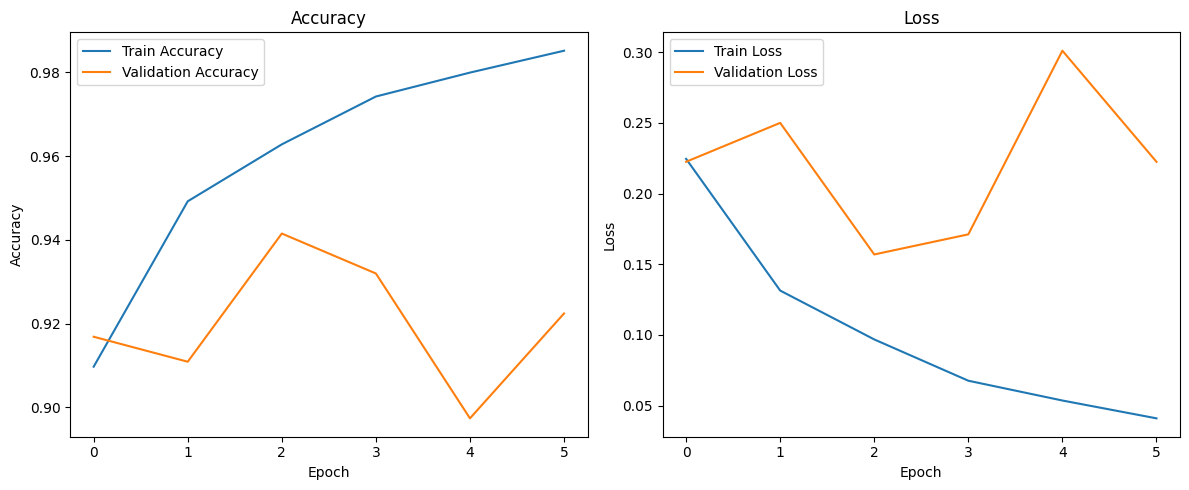

In [ ]:
# accuracy and loss graphs

plt.figure(figsize=(12,5))

# Plot training and validation accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Plot training and validation loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 194ms/step


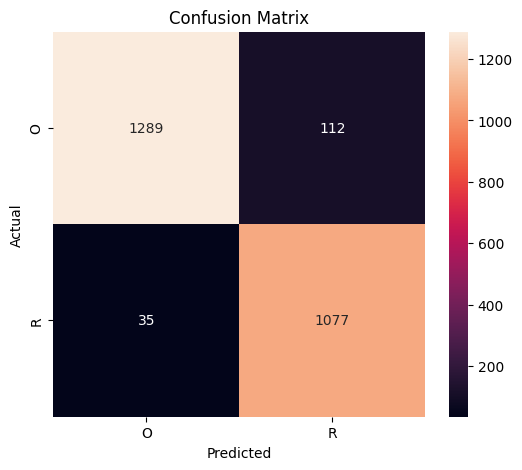


Classification Report:

              precision    recall  f1-score   support

           O       0.97      0.92      0.95      1401
           R       0.91      0.97      0.94      1112

    accuracy                           0.94      2513
   macro avg       0.94      0.94      0.94      2513
weighted avg       0.94      0.94      0.94      2513



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get model predictions on the test dataset
Y_pred = model.predict(test_data)
# Convert predicted probabilities to class labels (0 or 1)
y_pred = np.argmax(Y_pred, axis=1)

# Generate the confusion matrix
cm = confusion_matrix(test_data.classes, y_pred)

# Plot the confusion matrix using a heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=train_data.class_indices.keys(), # Predicted labels
            yticklabels=train_data.class_indices.keys()) # Actual labels
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Print the classification report, which includes precision, recall, and f1-score
print("\nClassification Report:\n")
print(classification_report(test_data.classes, y_pred,
                            target_names=list(train_data.class_indices.keys())))

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


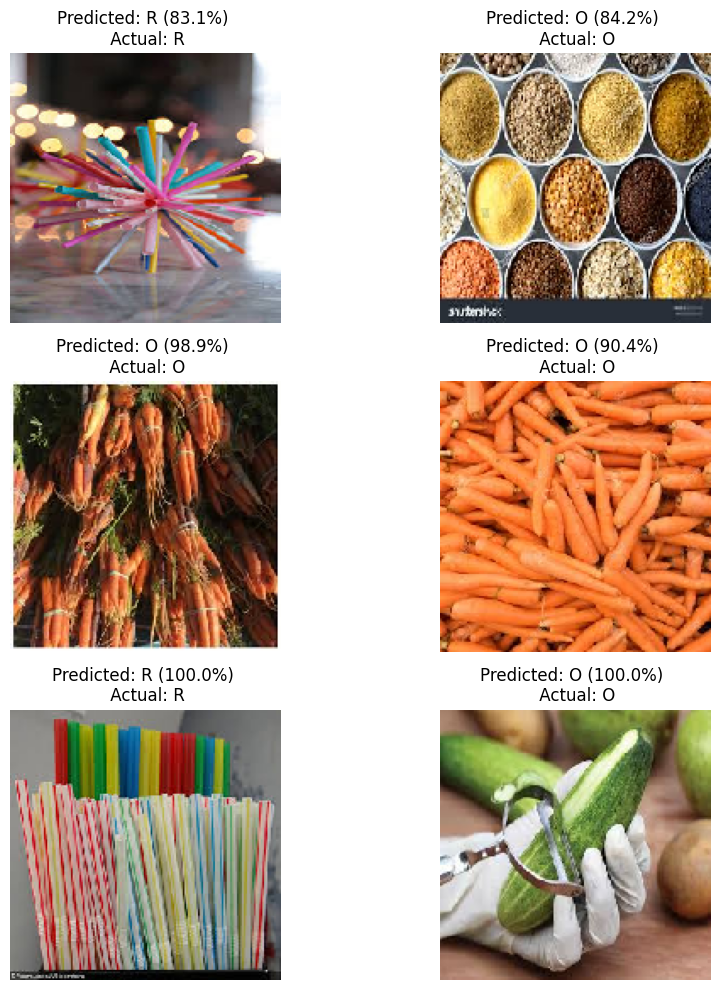

In [ ]:
import random

# Get class labels from the training data generator
class_labels = list(train_data.class_indices.keys())

plt.figure(figsize=(10,10))

# Loop to display and predict on 6 random images from the test set
for i in range(6):
    # Select a random index for an image in the test dataset
    idx = random.randint(0, len(test_data.filepaths)-1)
    img_path = test_data.filepaths[idx]

    # Load and preprocess the image
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.keras.preprocessing.image.img_to_array(img)/255.0 # Convert to array and normalize
    img_array = np.expand_dims(img_array, axis=0) # Add batch dimension

    # Make a prediction with the trained model
    pred = model.predict(img_array)
    # Get the predicted class label and its confidence
    label = class_labels[np.argmax(pred)]
    confidence = np.max(pred)*100

    # Plot the image with its predicted label and confidence
    plt.subplot(3,2,i+1)
    plt.imshow(img)
    plt.title(f"Predicted: {label} ({confidence:.1f}%) \n Actual: {class_labels[test_data.classes[idx]]}") # Display predicted and actual labels
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Save the trained model to a file in the native Keras format
# The .keras extension indicates the new Keras v3 format
model.save("waste_model.keras")
print("Model saved!")

Model saved!
